# 01 · Data exploration

**Question:** can EZ Tech (a fictional B2B SaaS company) rely on its annual budget, or does it need a rolling forecast? The data is a synthetic ERP general-ledger export shaped like NetSuite/SAP, messiness included.

**Key findings**
1. The raw extract needs cleaning. Once cleaned, the P&L ties to the ledger to the penny.
2. Seasonality is stable, and ARR and headcount explain the biggest lines.
3. The budget misses by double digits in every full year, which is the case for a rolling forecast.

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
from statsmodels.tsa.seasonal import STL

from fpa import viz
from fpa.viz import ROLE, plt, usd, usd_axis
from matplotlib.ticker import FuncFormatter

viz.use_style()
pd.set_option("display.float_format", lambda v: f"{v:,.0f}")
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RAW, MARTS = ROOT / "data" / "raw", ROOT / "data" / "marts"
meta = json.loads((MARTS / "run_metadata.json").read_text())
print(f"{meta['company']} | books closed through {meta['as_of']}")

EZ Tech, Inc. | books closed through 2026-09


## 1. What does the raw data look like, and is it clean?

One row per journal-entry line, as it leaves the ERP. Every entry must balance (debits = credits).

In [2]:
gl = pd.read_csv(RAW / "gl_journal_lines.csv", dtype=str, keep_default_na=False)
print(f"{len(gl):,} lines | {gl['je_id'].nunique():,} journal entries | periods {gl['period'].min()} to {gl['period'].max()}")
gl.sample(5, random_state=3)[["period", "account", "cost_center", "vendor_name", "description", "debit", "credit", "source"]]

90,841 lines | 13,085 journal entries | periods 2021-01 to 2026-09


,period,account,cost_center,vendor_name,description,debit,credit,source
2807,2021-04,4000,CC-000,,Subscription revenue - Maplepeak Health,,529.71,REVREC
18766,2022-08,4000,CC-000,,Subscription revenue - Irongate Health,,2344.84,REVREC
65831,2025-07,4000,CC-000,,Subscription revenue - Prairielight Manufacturing,,1065.08,REVREC
1465,2021-02,6500,CC-210,Corporate Card Program,Expense report E210003 - Client entertainment,52.21,,AP
82051,2026-05,4000,CC-000,,SUBSCRIPTION REVENUE - PRAIRIEVIEW REALTY,,1963.34,REVREC


In [3]:
dq, rec = meta["data_quality"], meta["reconciliation"]
pd.Series({
    "Lines loaded": f"{dq['rows_loaded']:,}",
    "Duplicate extract lines removed": dq["extract_duplicate_lines"],
    "Missing or invalid cost centers (imputed)": dq["pnl_lines_blank_cost_center"] + dq["pnl_lines_invalid_cost_center"],
    "Journal entries out of balance (after de-dupe)": dq["unbalanced_jes_after_dedupe"],
    "Breaks vs the ERP's control totals": dq["control_total_breaks"],
    "Possible duplicate invoices (sent to AP, not deleted)": len(dq["possible_duplicate_invoices"]),
    "P&L vs ledger difference": f"${rec['gl_to_pnl_mart_diff_usd']:,.2f}",
}, name="result").to_frame()

,result
Lines loaded,"90,841"
Duplicate extract lines removed,81
Missing or invalid cost centers (imputed),54
Journal entries out of balance (after de-dupe),0
Breaks vs the ERP's control totals,0
"Possible duplicate invoices (sent to AP, not deleted)",6
P&L vs ledger difference,$0.00


## 2. How has the business performed?

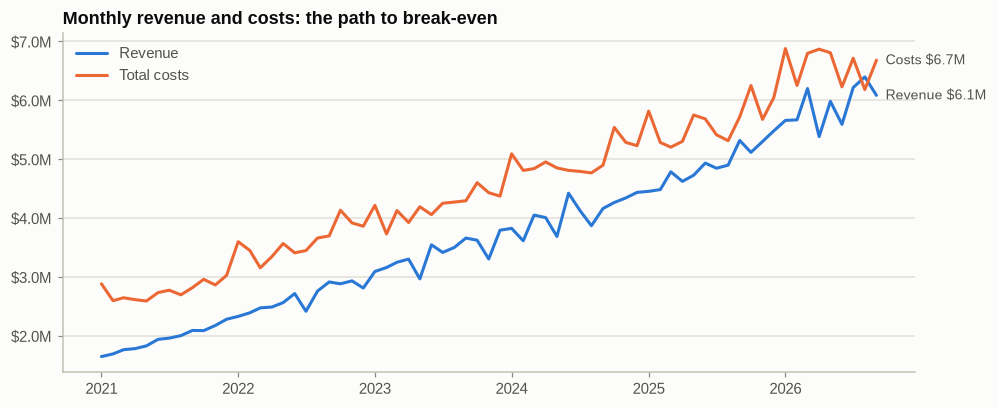

In [4]:
pnl = pd.read_parquet(MARTS / "fct_monthly_pnl.parquet")
pnl["ds"] = pd.PeriodIndex(pnl["period"], freq="M").to_timestamp()
pnl["group"] = np.where(pnl["account_type"] == "Revenue", "Revenue", "Costs")
monthly = pnl.pivot_table(index="ds", columns="group", values="actual_usd", aggfunc="sum")

fig, ax = plt.subplots()
ax.plot(monthly.index, monthly["Revenue"], color=ROLE["actual"], label="Revenue")
ax.plot(monthly.index, monthly["Costs"], color=viz.SERIES[1], label="Total costs")
for col in ("Revenue", "Costs"):
    viz.end_label(ax, monthly.index[-1], monthly[col].iloc[-1], f"{col} {usd(monthly[col].iloc[-1])}")
usd_axis(ax)
ax.set_title("Monthly revenue and costs: the path to break-even")
ax.legend(loc="upper left")
plt.show()

Revenue grew from about $1.7M to about $6M a month while costs grew more slowly, taking the company from deep losses to around break-even. A hiring freeze (Nov-22), the loss of the largest customer (Jul-24) and a price increase (Jul-25) all shape this history.

## 3. What patterns must a forecast capture?

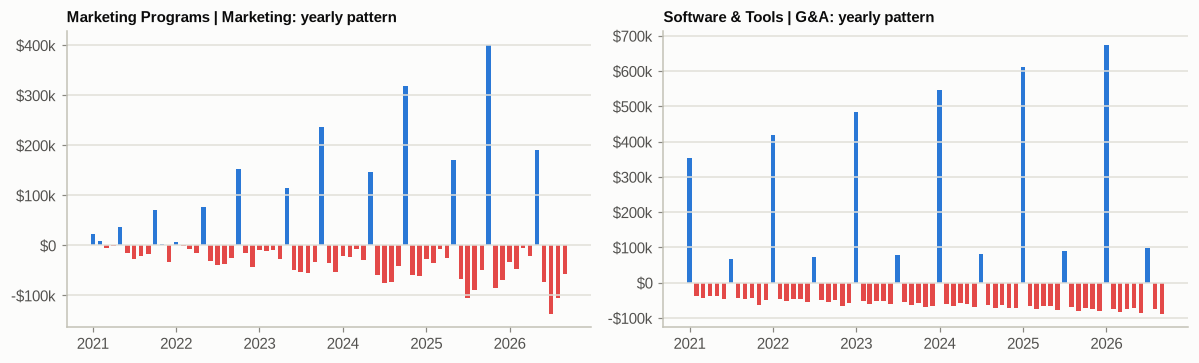

In [5]:
series = pnl.assign(unique_id=pnl["fs_line"] + " | " + pnl["department"]).pivot_table(index="ds", columns="unique_id", values="actual_usd")
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
for ax, name in zip(axes, ["Marketing Programs | Marketing", "Software & Tools | G&A"]):
    seasonal = STL(series[name].fillna(0).to_numpy(), period=12, robust=True).fit().seasonal
    ax.bar(series.index, seasonal, width=20, color=np.where(seasonal >= 0, viz.SERIES[0], viz.SERIES[7]))
    ax.set_title(f"{name}: yearly pattern", fontsize=10)
    usd_axis(ax)
fig.tight_layout()
plt.show()

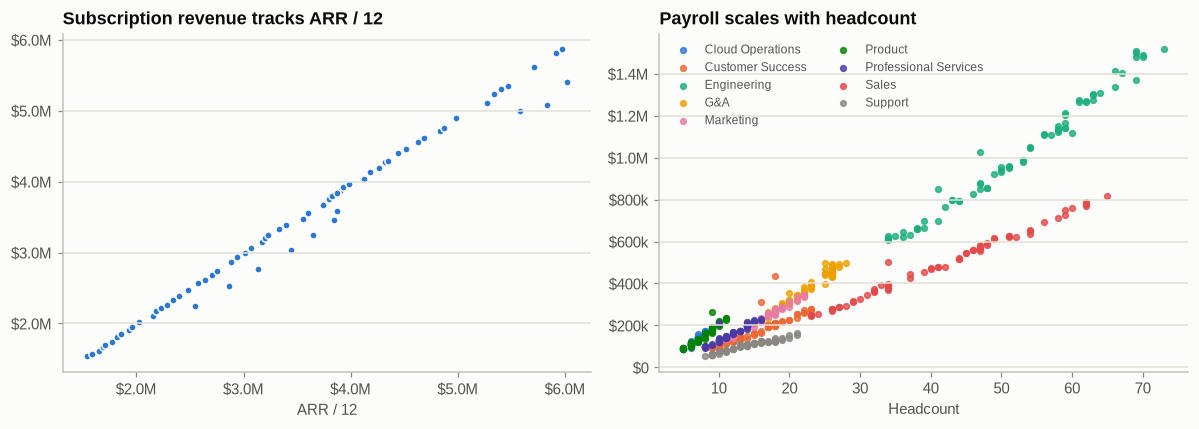

In [6]:
arr = pd.read_parquet(MARTS / "fct_arr.parquet")
arr["ds"] = pd.PeriodIndex(arr["period"], freq="M").to_timestamp()
hc = pd.read_parquet(MARTS / "fct_headcount.parquet")
hc["ds"] = pd.PeriodIndex(hc["period"], freq="M").to_timestamp()

fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4))
rev = series["Subscription Revenue | Company"]
a1.scatter(arr.set_index("ds")["ending_arr"].reindex(rev.index) / 12, rev, s=22, color=viz.SERIES[0], edgecolor=viz.SURFACE, linewidth=1)
a1.set_title("Subscription revenue tracks ARR / 12")
a1.set_xlabel("ARR / 12"); usd_axis(a1); usd_axis(a1, "x")

pers = pnl[pnl["fs_line"] == "Personnel"].merge(hc, on=["ds", "department"])
for i, (dept, g) in enumerate(pers.groupby("department")):
    a2.scatter(g["headcount"], g["actual_usd"], s=14, color=viz.SERIES[i % 8] if i < 8 else viz.MUTED, label=dept, alpha=0.8)
a2.set_title("Payroll scales with headcount")
a2.set_xlabel("Headcount"); usd_axis(a2)
a2.legend(fontsize=8, ncol=2)
fig.tight_layout()
plt.show()

- **Seasonality:** marketing peaks with the May trade show and the October conference. Software spikes every January when licences renew.
- **Drivers:** revenue follows ARR and payroll follows headcount. So an **ARR run-rate** model competes for revenue, and the **headcount plan** feeds the machine-learning model.

## 4. How good is the annual budget?

The budget is locked every November with stretch targets and cannot foresee churn, price changes or one-offs. I measure its error as **WAPE**: total absolute miss ÷ total actuals.

In [7]:
bud = pd.read_parquet(MARTS / "fct_budget_monthly.parquet")
bud["unique_id"] = bud["fs_line"] + " | " + bud["department"]
act = pnl.assign(unique_id=pnl["fs_line"] + " | " + pnl["department"])
both = act.merge(bud[["unique_id", "period", "budget_usd"]], on=["unique_id", "period"])
both["year"] = both["period"].str[:4]

def wape(g):
    return np.abs(g["actual_usd"] - g["budget_usd"]).sum() / g["actual_usd"].abs().sum()

by_year = both.groupby("year").apply(wape, include_groups=False)
print("Budget error (WAPE) by year: " + " · ".join(f"{y} {v:.0%}" for y, v in by_year.items()) + "  (latest year is year-to-date)")

Budget error (WAPE) by year: 2021 12% · 2022 16% · 2023 15% · 2024 12% · 2025 11% · 2026 10%  (latest year is year-to-date)


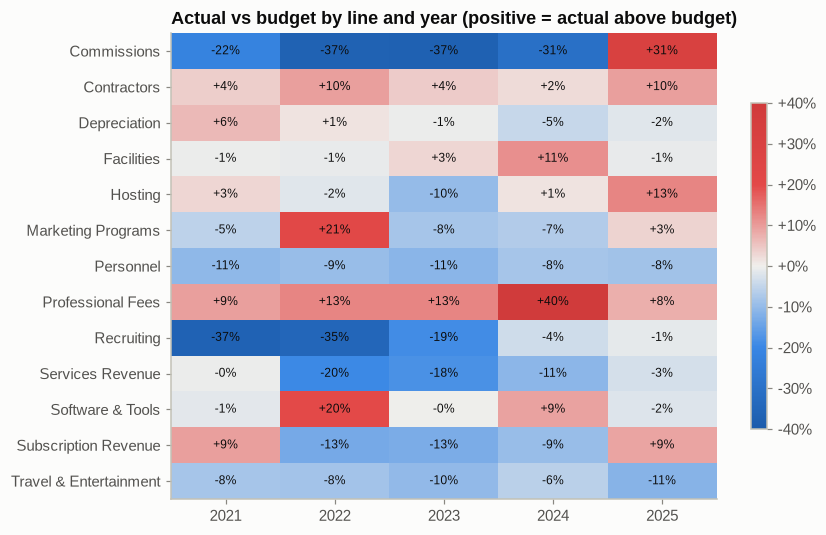

In [8]:
# Full-year actual vs budget by P&L line (% over / under)
full_years = both[both["year"] < meta["as_of"][:4]]
line = full_years.groupby(["fs_line", "year"])[["actual_usd", "budget_usd"]].sum()
gap = (line["actual_usd"] / line["budget_usd"] - 1).unstack()

fig, ax = plt.subplots(figsize=(8, 5.5))
im = ax.imshow(gap.clip(-0.4, 0.4), cmap=viz.DIVERGING.reversed(), vmin=-0.4, vmax=0.4, aspect="auto")
ax.set_xticks(range(gap.shape[1]), gap.columns); ax.set_yticks(range(gap.shape[0]), gap.index)
for (i, j), v in np.ndenumerate(gap.to_numpy()):
    ax.text(j, i, f"{v:+.0%}", ha="center", va="center", fontsize=8, color=viz.INK)
ax.grid(False)
ax.set_title("Actual vs budget by line and year (positive = actual above budget)")
fig.colorbar(im, ax=ax, format=FuncFormatter(lambda v, _: f"{v:+.0%}"), shrink=0.7)
plt.show()

Some misses are systematic: payroll under-runs because hires land later than planned. Others are shocks, such as losing the largest customer in 2024. A budget is a target, not a forecast.

**Next:** [notebook 02](02_forecast_backtesting.ipynb) tests whether a rolling forecast does better.